<a href="https://colab.research.google.com/github/jungeun1228/2026_06_OASIS_specificity-analysis/blob/main/CelllProfiler_QC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This is raw data files from Ewald et al. (2026) - https://github.com/jessica-ewald/2024_09_09_Axiom_OASIS
# A Python file from the following location was executed in the terminal to download a compiled input file:
# 2024_09_09_Axiom_OASIS/0_prepare_data/4A_download_compiled_inputs.py
# raw.parquet from DINO

import pandas as pd
import numpy as np
import requests

!pip install -q gdown
!gdown --id 1znqthwcngAsXiru-z7DTfTfEJEN_W95J -O /content/cellprofiler_raw.parquet

/usr/local/lib/python3.13/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1znqthwcngAsXiru-z7DTfTfEJEN_W95J
From (redirected): https://drive.google.com/uc?id=1znqthwcngAsXiru-z7DTfTfEJEN_W95J&confirm=t&uuid=abc12774-e54d-4509-a766-7174a6fd9a3f
To: /content/cellprofiler_raw.parquet
100% 413M/413M [00:06<00:00, 67.1MB/s]


In [ ]:
df_cellprofiler = pd.read_parquet("cellprofiler_raw.parquet")
df_cellprofiler.head(15)

,Metadata_well_id,Metadata_source,Metadata_Plate,Metadata_Concentration,Metadata_Compound,Metadata_compound_target,Metadata_compound_pathway,Metadata_compound_research_area,Metadata_compound_clinical_information,Metadata_Well,...,Nuclei_Texture_Variance_RNA_10_02_256,Nuclei_Texture_Variance_RNA_10_03_256,Nuclei_Texture_Variance_RNA_3_00_256,Nuclei_Texture_Variance_RNA_3_01_256,Nuclei_Texture_Variance_RNA_3_02_256,Nuclei_Texture_Variance_RNA_3_03_256,Nuclei_Texture_Variance_RNA_5_00_256,Nuclei_Texture_Variance_RNA_5_01_256,Nuclei_Texture_Variance_RNA_5_02_256,Nuclei_Texture_Variance_RNA_5_03_256
0,assayworks_prod_26_p=plate_41002878_r=0_c=0,assayworks_prod_26,plate_41002878,100.0,"1,4-Dibromobenzene",None,None,None,No Development Reported,A01,...,3.0341,3.1077,2.9159,2.9334,2.9132,2.9362,2.9490,2.9822,2.9453,2.9872
1,assayworks_prod_26_p=plate_41002878_r=0_c=1,assayworks_prod_26,plate_41002878,100.0,"2,2,3,3,4,4,5,5,6,6,7,7,8,8,9,9,9-Heptadecaflu...",None,None,None,None,A02,...,2.3187,2.3546,2.2794,2.2829,2.2794,2.2841,2.2871,2.2982,2.2865,2.3010
2,assayworks_prod_26_p=plate_41002878_r=0_c=2,assayworks_prod_26,plate_41002878,100.0,Calcifediol,Endogenous Metabolite; VD/VDR,Metabolic Enzyme/Protease; Vitamin D Related/N...,Metabolic Disease,Launched,A03,...,3.0126,3.0278,3.0800,3.0518,3.0812,3.0445,3.0351,3.0170,3.0377,3.0064
3,assayworks_prod_26_p=plate_41002878_r=0_c=3,assayworks_prod_26,plate_41002878,0.0,DMSO,None,None,None,None,A04,...,2.9056,2.9468,2.8565,2.8604,2.8541,2.8584,2.8663,2.8793,2.8639,2.8785
4,assayworks_prod_26_p=plate_41002878_r=0_c=4,assayworks_prod_26,plate_41002878,100.0,DHEA,Androgen Receptor; Endogenous Metabolite,Metabolic Enzyme/Protease; Vitamin D Related/N...,Endocrinology; Cancer,Launched,A05,...,2.3178,2.3498,2.2871,2.2889,2.2830,2.2899,2.2960,2.3024,2.2894,2.3049
5,assayworks_prod_26_p=plate_41002878_r=0_c=5,assayworks_prod_26,plate_41002878,100.0,Enfuvirtide,HIV,Anti-infection,Infection,Launched,A06,...,2.9126,2.9553,2.8840,2.8866,2.8757,2.8825,2.8941,2.9033,2.8815,2.8994
6,assayworks_prod_26_p=plate_41002878_r=0_c=6,assayworks_prod_26,plate_41002878,100.0,L-Ethionine,Amino Acid Derivatives,Others,Others,No Development Reported,A07,...,2.0962,2.1381,2.0182,2.0321,2.0162,2.0274,2.0397,2.0661,2.0368,2.0590
7,assayworks_prod_26_p=plate_41002878_r=0_c=7,assayworks_prod_26,plate_41002878,100.0,Zolmitriptan,5-HT Receptor; Endogenous Metabolite,GPCR/G Protein; Metabolic Enzyme/Protease; Neu...,Neurological Disease,Launched,A08,...,2.8132,2.8467,2.7581,2.7683,2.7536,2.7611,2.7743,2.7952,2.7677,2.7838
8,assayworks_prod_26_p=plate_41002878_r=0_c=8,assayworks_prod_26,plate_41002878,100.0,Nandrolone decanoate,Androgen Receptor; HIV,Anti-infection; Vitamin D Related/Nuclear Rece...,Infection; Endocrinology; Metabolic Disease,Launched,A09,...,2.5385,2.5654,2.4968,2.4980,2.5033,2.5033,2.4993,2.5092,2.5073,2.5164
9,assayworks_prod_26_p=plate_41002878_r=0_c=9,assayworks_prod_26,plate_41002878,100.0,Compound_04264751,None,None,None,None,A10,...,2.2737,2.3180,2.2178,2.2228,2.2153,2.2239,2.2315,2.2454,2.2269,2.2480


# Features

### (1) Explore

In [ ]:
compartments = ["Cells", "Nuclei", "Cytoplasm"]
channels = ["AGP", "DNA", "ER", "Mito", "RNA"]

def get_feature_group(col):

    # Image-level features 제외
    if col.startswith("Image_"):
        return None

    compartment = col.split("_", 1)[0]

    if compartment not in compartments:
        return None

    # AreaShape: channel-independent
    if "_AreaShape_" in col:
        return f"{compartment}_AreaShape"

    # channel-dependent features
    for channel in channels:
        if f"_{channel}_" in col or col.endswith(f"_{channel}"):
            return f"{compartment}_{channel}"

    return None

In [ ]:
feature_groups = {}

for col in df_cellprofiler.columns:
    group = get_feature_group(col)

    if group is not None:
        feature_groups.setdefault(group, []).append(col)

In [ ]:
for group in sorted(feature_groups):
    print(group, len(feature_groups[group]))

Cells_AGP 245
Cells_AreaShape 55
Cells_DNA 237
Cells_ER 229
Cells_Mito 221
Cells_RNA 213
Cytoplasm_AGP 245
Cytoplasm_AreaShape 55
Cytoplasm_DNA 237
Cytoplasm_ER 229
Cytoplasm_Mito 221
Cytoplasm_RNA 213
Nuclei_AGP 245
Nuclei_AreaShape 55
Nuclei_DNA 237
Nuclei_ER 229
Nuclei_Mito 221
Nuclei_RNA 213


In [ ]:
feature_cols = [
    c for c in df_cellprofiler.columns
    if c.startswith(("Cells_", "Nuclei_", "Cytoplasm_"))
]

combos = []

for c in feature_cols:
    parts = c.split("_")

    combos.append({
        "col": c,
        "word1": parts[0] if len(parts) > 0 else None,
        "word2": parts[1] if len(parts) > 1 else None,
        "word4": parts[3] if len(parts) > 3 else None,
    })

combo_df = pd.DataFrame(combos)

In [ ]:
combo_summary = (
    combo_df
    .groupby(["word1", "word2", "word4"])
    .size()
    .reset_index(name="n_features")
    .sort_values(["word1", "word2", "word4"])
)

pd.set_option("display.max_rows", None)
print(combo_summary)

         word1               word2        word4  n_features
0        Cells           AreaShape            0           1
1        Cells           AreaShape            1           1
2        Cells           AreaShape            2           2
3        Cells           AreaShape            3           2
4        Cells           AreaShape            4           3
5        Cells           AreaShape            5           3
6        Cells           AreaShape            6           4
7        Cells           AreaShape            7           4
8        Cells           AreaShape            8           5
9        Cells           AreaShape            9           5
10       Cells           AreaShape            X           3
11       Cells           AreaShape            Y           3
12       Cells            Children        Count           1
13       Cells         Correlation          AGP          25
14       Cells         Correlation  Brightfield          23
15       Cells         Correlation      

In [ ]:
corr_cols = [
    c for c in feature_cols
    if "_Correlation_" in c
]

corr_cols[:30]

['Cells_Correlation_Correlation_AGP_Brightfield',
 'Cells_Correlation_Correlation_AGP_DNA',
 'Cells_Correlation_Correlation_AGP_ER',
 'Cells_Correlation_Correlation_AGP_Mito',
 'Cells_Correlation_Correlation_AGP_RNA',
 'Cells_Correlation_Correlation_Brightfield_DNA',
 'Cells_Correlation_Correlation_Brightfield_ER',
 'Cells_Correlation_Correlation_Brightfield_Mito',
 'Cells_Correlation_Correlation_Brightfield_RNA',
 'Cells_Correlation_Correlation_DNA_ER',
 'Cells_Correlation_Correlation_DNA_Mito',
 'Cells_Correlation_Correlation_DNA_RNA',
 'Cells_Correlation_Correlation_ER_Mito',
 'Cells_Correlation_Correlation_ER_RNA',
 'Cells_Correlation_Correlation_Mito_RNA',
 'Cells_Correlation_K_AGP_Brightfield',
 'Cells_Correlation_K_AGP_DNA',
 'Cells_Correlation_K_AGP_ER',
 'Cells_Correlation_K_AGP_Mito',
 'Cells_Correlation_K_AGP_RNA',
 'Cells_Correlation_K_Brightfield_AGP',
 'Cells_Correlation_K_Brightfield_DNA',
 'Cells_Correlation_K_Brightfield_ER',
 'Cells_Correlation_K_Brightfield_Mito',
 '

### (2) Compartments X channels/areashape: 3 X 6 = 18

In [ ]:
compartments = ["Cells", "Nuclei", "Cytoplasm"]
channels = ["AGP", "DNA", "ER", "Mito", "RNA"]

channel_families = {
    "Intensity",
    "Texture",
    "Granularity",
    "RadialDistribution",
}

exclude_families = {
    "Correlation",
    "Location",
    "Neighbors",
    "Number",
    "Parent",
    "Children",
    "ObjectSkeleton",
}

feature_groups = {
    f"{comp}_{ch}": []
    for comp in compartments
    for ch in channels
}

for comp in compartments:
    feature_groups[f"{comp}_AreaShape"] = []


for col in df_cellprofiler.columns:

    # Metadata / image-level 제외
    if col.startswith("Metadata") or col.startswith("Image_"):
        continue

    parts = col.split("_")

    if len(parts) < 2:
        continue

    compartment = parts[0]
    family = parts[1]

    if compartment not in compartments:
        continue

    # 1. AreaShape
    if family == "AreaShape":
        feature_groups[f"{compartment}_AreaShape"].append(col)
        continue

    # 2. 명확한 single-channel feature family
    if family in channel_families:
        matched_channels = [
            ch for ch in channels
            if ch in parts
        ]

        # 원칙적으로 하나의 channel만 잡혀야 함
        if len(matched_channels) == 1:
            ch = matched_channels[0]
            feature_groups[f"{compartment}_{ch}"].append(col)

        elif len(matched_channels) > 1:
            print("Multiple channels found:", col, matched_channels)

        else:
            print("No channel found:", col)

        continue

    # 나머지 family는 현재 분석에서 제외

No channel found: Cells_Granularity_10_Brightfield
No channel found: Cells_Granularity_11_Brightfield
No channel found: Cells_Granularity_12_Brightfield
No channel found: Cells_Granularity_13_Brightfield
No channel found: Cells_Granularity_14_Brightfield
No channel found: Cells_Granularity_15_Brightfield
No channel found: Cells_Granularity_16_Brightfield
No channel found: Cells_Granularity_1_Brightfield
No channel found: Cells_Granularity_2_Brightfield
No channel found: Cells_Granularity_3_Brightfield
No channel found: Cells_Granularity_4_Brightfield
No channel found: Cells_Granularity_5_Brightfield
No channel found: Cells_Granularity_6_Brightfield
No channel found: Cells_Granularity_7_Brightfield
No channel found: Cells_Granularity_8_Brightfield
No channel found: Cells_Granularity_9_Brightfield
No channel found: Cells_Intensity_IntegratedIntensityEdge_Brightfield
No channel found: Cells_Intensity_IntegratedIntensity_Brightfield
No channel found: Cells_Intensity_LowerQuartileIntensity_

In [ ]:
# feature_groups: dictionary (key=groups : values=column names)
for group in sorted(feature_groups):
    print(group, len(feature_groups[group]))

Cells_AGP 199
Cells_AreaShape 55
Cells_DNA 199
Cells_ER 199
Cells_Mito 199
Cells_RNA 199
Cytoplasm_AGP 199
Cytoplasm_AreaShape 55
Cytoplasm_DNA 199
Cytoplasm_ER 199
Cytoplasm_Mito 199
Cytoplasm_RNA 199
Nuclei_AGP 199
Nuclei_AreaShape 55
Nuclei_DNA 199
Nuclei_ER 199
Nuclei_Mito 199
Nuclei_RNA 199


In [ ]:
n_selected = sum(len(v) for v in feature_groups.values())
print("Selected features:", n_selected)

Selected features: 3150


In [ ]:
# Excluded features
from collections import Counter

excluded = Counter()

for col in df_cellprofiler.columns:
    if not col.startswith(("Cells_", "Nuclei_", "Cytoplasm_")):
        continue

    parts = col.split("_")
    if len(parts) < 2:
        continue

    family = parts[1]

    if family not in channel_families and family != "AreaShape":
        excluded[family] += 1

print(excluded)

Counter({'Correlation': 360, 'Location': 113, 'Neighbors': 21, 'ObjectSkeleton': 4, 'Children': 2, 'Number': 2, 'Parent': 1})


In [ ]:
feature_cols = [
    feature
    for features in feature_groups.values()
    for feature in features
]

In [ ]:
len(feature_cols), len(set(feature_cols))

(3150, 3150)

# Remove duplicated rows

In [ ]:
# Check duplicates
print(
    "exact duplicates:",
    df_cellprofiler.duplicated().sum()
)

df_cellprofiler = (
    df_cellprofiler
    .drop_duplicates()
    .reset_index(drop=True)
)

print(
    "remaining duplicated plate-wells:",
    df_cellprofiler[
        ["Metadata_Plate", "Metadata_Well"]
    ].duplicated().sum()
)

exact duplicates: 136
remaining duplicated plate-wells: 14


In [ ]:
dup_pw = df_cellprofiler[
    df_cellprofiler.duplicated(
        ["Metadata_Plate", "Metadata_Well"],
        keep=False
    )
].sort_values(["Metadata_Plate", "Metadata_Well"])

In [ ]:
dup_pw

,Metadata_well_id,Metadata_source,Metadata_Plate,Metadata_Concentration,Metadata_Compound,Metadata_compound_target,Metadata_compound_pathway,Metadata_compound_research_area,Metadata_compound_clinical_information,Metadata_Well,...,Nuclei_Texture_Variance_RNA_10_02_256,Nuclei_Texture_Variance_RNA_10_03_256,Nuclei_Texture_Variance_RNA_3_00_256,Nuclei_Texture_Variance_RNA_3_01_256,Nuclei_Texture_Variance_RNA_3_02_256,Nuclei_Texture_Variance_RNA_3_03_256,Nuclei_Texture_Variance_RNA_5_00_256,Nuclei_Texture_Variance_RNA_5_01_256,Nuclei_Texture_Variance_RNA_5_02_256,Nuclei_Texture_Variance_RNA_5_03_256
19546,assayworks_prod_25_p=plate_41002689_r=14_c=22,assayworks_prod_25,plate_41002689,3.500000,Vasopressin,Endogenous Metabolite,Metabolic Enzyme/Protease,Neurological Disease,Launched,O23,...,1.5557,1.5712,1.5298,1.5335,1.5267,1.5301,1.5373,1.5468,1.5323,1.5413
19547,assayworks_prod_25_p=plate_41002689_r=14_c=22,assayworks_prod_25,plate_41002689,3.500000,Vasopressin,Endogenous Metabolite,Metabolic Enzyme/Protease,Neurological Disease,Launched,O23,...,1.5557,1.5712,1.5298,1.5335,1.5267,1.5301,1.5373,1.5468,1.5323,1.5413
16414,assayworks_prod_25_p=plate_41002691_r=14_c=10,assayworks_prod_25,plate_41002691,0.045643,Vasopressin,Endogenous Metabolite,Metabolic Enzyme/Protease,Neurological Disease,Launched,O11,...,1.5085,1.5301,1.4558,1.4653,1.4582,1.4647,1.4682,1.4857,1.4717,1.4847
16415,assayworks_prod_25_p=plate_41002691_r=14_c=10,assayworks_prod_25,plate_41002691,0.045643,Vasopressin,Endogenous Metabolite,Metabolic Enzyme/Protease,Neurological Disease,Launched,O11,...,1.5085,1.5301,1.4558,1.4653,1.4582,1.4647,1.4682,1.4857,1.4717,1.4847
1757,assayworks_prod_25_p=plate_41002692_r=14_c=4,assayworks_prod_25,plate_41002692,100.000000,Vasopressin,Endogenous Metabolite,Metabolic Enzyme/Protease,Neurological Disease,Launched,O05,...,1.9301,1.9587,1.8625,1.8748,1.8622,1.8716,1.8812,1.9037,1.8804,1.8980
1758,assayworks_prod_25_p=plate_41002692_r=14_c=4,assayworks_prod_25,plate_41002692,100.000000,Vasopressin,Endogenous Metabolite,Metabolic Enzyme/Protease,Neurological Disease,Launched,O05,...,1.9301,1.9587,1.8625,1.8748,1.8622,1.8716,1.8812,1.9037,1.8804,1.8980
6572,assayworks_prod_25_p=plate_41002694_r=14_c=4,assayworks_prod_25,plate_41002694,1.000000,Vasopressin,Endogenous Metabolite,Metabolic Enzyme/Protease,Neurological Disease,Launched,O05,...,1.5224,1.5443,1.4738,1.4825,1.4730,1.4795,1.4856,1.5031,1.4850,1.4984
6573,assayworks_prod_25_p=plate_41002694_r=14_c=4,assayworks_prod_25,plate_41002694,1.000000,Vasopressin,Endogenous Metabolite,Metabolic Enzyme/Protease,Neurological Disease,Launched,O05,...,1.5224,1.5443,1.4738,1.4825,1.4730,1.4795,1.4856,1.5031,1.4850,1.4984
14125,assayworks_prod_25_p=plate_41002701_r=14_c=23,assayworks_prod_25,plate_41002701,33.500000,Vasopressin,Endogenous Metabolite,Metabolic Enzyme/Protease,Neurological Disease,Launched,O24,...,1.2189,1.2299,1.2245,1.2181,1.2242,1.2199,1.2174,1.2145,1.2166,1.2174
14126,assayworks_prod_25_p=plate_41002701_r=14_c=23,assayworks_prod_25,plate_41002701,33.500000,Vasopressin,Endogenous Metabolite,Metabolic Enzyme/Protease,Neurological Disease,Launched,O24,...,1.2189,1.2299,1.2245,1.2181,1.2242,1.2199,1.2174,1.2145,1.2166,1.2174


In [ ]:
dup_pw = df_cellprofiler[
    df_cellprofiler.duplicated(
        ["Metadata_Plate", "Metadata_Well"],
        keep=False
    )
].sort_values(["Metadata_Plate", "Metadata_Well"])

In [ ]:
for (plate, well), g in dup_pw.groupby(
    ["Metadata_Plate", "Metadata_Well"]
):
    print(f"\n### {plate} / {well}")

    # 이 duplicate pair에서 값이 서로 다른 column
    different_cols = [
        col for col in g.columns
        if g[col].nunique(dropna=False) > 1
    ]

    print("Different columns:")
    print(different_cols)


### plate_41002689 / O23
Different columns:
['Metadata_OASIS_ID']

### plate_41002691 / O11
Different columns:
['Metadata_OASIS_ID']

### plate_41002692 / O05
Different columns:
['Metadata_OASIS_ID']

### plate_41002694 / O05
Different columns:
['Metadata_OASIS_ID']

### plate_41002701 / O24
Different columns:
['Metadata_OASIS_ID']

### plate_41002703 / O11
Different columns:
['Metadata_OASIS_ID']

### plate_41002876 / J16
Different columns:
['Metadata_OASIS_ID']

### plate_41002878 / N22
Different columns:
['Metadata_OASIS_ID']

### plate_41002880 / M10
Different columns:
['Metadata_OASIS_ID']

### plate_41002882 / N22
Different columns:
['Metadata_OASIS_ID']

### plate_41002883 / L19
Different columns:
['Metadata_OASIS_ID']

### plate_41002885 / F13
Different columns:
['Metadata_OASIS_ID']

### plate_41002887 / L19
Different columns:
['Metadata_OASIS_ID']

### plate_41002889 / F14
Different columns:
['Metadata_OASIS_ID']


In [ ]:
for (plate, well), g in dup_pw.groupby(
    ["Metadata_Plate", "Metadata_Well"]
):

    different_features = [
        col for col in feature_cols
        if g[col].nunique(dropna=False) > 1
    ]

    print(
        plate,
        well,
        "different CP features:",
        len(different_features)
    )

plate_41002689 O23 different CP features: 0
plate_41002691 O11 different CP features: 0
plate_41002692 O05 different CP features: 0
plate_41002694 O05 different CP features: 0
plate_41002701 O24 different CP features: 0
plate_41002703 O11 different CP features: 0
plate_41002876 J16 different CP features: 0
plate_41002878 N22 different CP features: 0
plate_41002880 M10 different CP features: 0
plate_41002882 N22 different CP features: 0
plate_41002883 L19 different CP features: 0
plate_41002885 F13 different CP features: 0
plate_41002887 L19 different CP features: 0
plate_41002889 F14 different CP features: 0


In [ ]:
for (plate, well), g in dup_pw.groupby(
    ["Metadata_Plate", "Metadata_Well"]
):
    different_cols = [
        col for col in g.columns
        if g[col].nunique(dropna=False) > 1
    ]

    print(f"\n### {plate} / {well}")
    display(g[different_cols])


### plate_41002689 / O23


,Metadata_OASIS_ID
19546,OASIS679
19547,OASIS1751



### plate_41002691 / O11


,Metadata_OASIS_ID
16414,OASIS679
16415,OASIS1751



### plate_41002692 / O05


...

,Metadata_OASIS_ID
3855,OASIS679
3856,OASIS1751



### plate_41002887 / L19


,Metadata_OASIS_ID
2084,OASIS679
2085,OASIS1751



### plate_41002889 / F14


,Metadata_OASIS_ID
3088,OASIS679
3089,OASIS1751


In [ ]:
# How to deal with duplicates? -> Keep rows with vasopressin "OASIS1751"
# Based on OASIS compound list: https://oasisconsortium.org/oasis-compounds/
# Vasopressin: OASIS1751 / Vasopressin tannate: OASIS679
df_cellprofiler = df_cellprofiler[
    ~(
        (df_cellprofiler["Metadata_Compound"] == "Vasopressin")
        & (df_cellprofiler["Metadata_OASIS_ID"] != "OASIS1751")
    )
].reset_index(drop=True)

In [ ]:
df_cellprofiler[
    ["Metadata_Plate", "Metadata_Well"]
].duplicated().sum()

np.int64(0)

# sample/well QC
- nucleus/cytoplasm count가 비정상적으로 낮거나 서로 너무 다른 well


In [ ]:
[c for c in df_cellprofiler.columns if c.startswith("Metadata")][:50]

['Metadata_well_id',
 'Metadata_source',
 'Metadata_Plate',
 'Metadata_Concentration',
 'Metadata_Compound',
 'Metadata_compound_target',
 'Metadata_compound_pathway',
 'Metadata_compound_research_area',
 'Metadata_compound_clinical_information',
 'Metadata_Well',
 'Metadata_row',
 'Metadata_col',
 'Metadata_mtt_lumi',
 'Metadata_ldh_abs_signal',
 'Metadata_ldh_abs_background',
 'Metadata_ldh_abs',
 'Metadata_mtt_normalized',
 'Metadata_ldh_normalized',
 'Metadata_mtt_ridge_norm',
 'Metadata_ldh_ridge_norm',
 'Metadata_OASIS_ID',
 'Metadata_Perturbation',
 'Metadata_Log10Conc',
 'Metadata_Count_Cells',
 'Metadata_Site_Count',
 'Metadata_Count_Cells_right',
 'Metadata_Count_CellsIncludingEdges',
 'Metadata_Count_Cytoplasm',
 'Metadata_Count_Nuclei',
 'Metadata_Count_NucleiIncludingEdges',
 'Metadata_Object_Count']

In [ ]:
qc_cols = [
    "Metadata_Count_Cells",
    "Metadata_Count_Cytoplasm",
    "Metadata_Count_Nuclei",
    "Metadata_Site_Count",
]

df_cellprofiler[qc_cols].describe()

,Metadata_Count_Cells,Metadata_Count_Cytoplasm,Metadata_Count_Nuclei,Metadata_Site_Count
count,21305.000000,21305.000000,21305.000000,21305.000000
mean,758.046937,616.939357,616.939357,14.801643
std,144.730655,124.600901,124.600901,1.245076
min,1.000000,1.000000,1.000000,1.000000
25%,710.000000,574.000000,574.000000,15.000000
50%,786.000000,642.000000,642.000000,15.000000
75%,845.000000,693.000000,693.000000,15.000000
max,1349.000000,899.000000,899.000000,15.000000


In [ ]:
# cell count per plate
df_cellprofiler.groupby("Metadata_Plate")[
    "Metadata_Count_Cells"
].describe()

,count,mean,std,min,25%,50%,75%,max
Metadata_Plate,,,,,,,,
plate_41002687,160.0,678.243750,114.072566,429.0,597.25,709.5,763.75,887.0
plate_41002688,384.0,868.638021,64.961742,37.0,841.00,873.0,902.00,976.0
plate_41002689,383.0,862.968668,94.104871,8.0,837.00,871.0,908.00,1008.0
plate_41002690,384.0,695.065104,121.494924,37.0,591.00,720.5,788.25,944.0
plate_41002691,384.0,865.091146,56.847233,512.0,834.75,868.0,905.25,995.0
plate_41002692,384.0,704.661458,277.510558,1.0,696.25,821.0,872.00,1044.0
plate_41002693,384.0,717.828125,222.781190,2.0,699.00,783.5,845.75,1096.0
plate_41002694,384.0,808.619792,107.686258,15.0,766.25,815.0,873.25,981.0
plate_41002697,384.0,803.473958,78.199613,448.0,747.00,806.0,868.25,960.0


In [ ]:
# Check if Cytoplasm = Nuclei
(
    df_cellprofiler["Metadata_Count_Cytoplasm"]
    == df_cellprofiler["Metadata_Count_Nuclei"]
).mean()

np.float64(1.0)

In [ ]:
# count wells per plate
plate_counts = (
    df_cellprofiler
    .groupby("Metadata_Plate")
    .size()
    .sort_values()
)

plate_counts

,0
Metadata_Plate,
plate_41002951,159
plate_41002956,159
plate_41002687,160
plate_41002891,160
plate_41002908,160
plate_41002960,160
plate_41002958,169
plate_41002955,169
plate_41002947,169


In [ ]:
plate_counts.describe()

,0
count,65.000000
mean,327.769231
std,87.717902
min,159.000000
25%,255.000000
50%,384.000000
75%,384.000000
max,384.000000


In [ ]:
# Check negative control
df_cellprofiler["Metadata_Compound"].value_counts().head(10)

,count
Metadata_Compound,
DMSO,4849
Compound_04264751,64
Diallyl phthalate,16
"4-(tert-Butyl)benzene-1,2-diol",16
Palbociclib,16
Tacrolimus,16
Actinomycin D,16
"1,4-Benzodinitrile",16
4-Nitrobenzoic acid,16


In [ ]:
# Check dmso per plate
dmso_per_plate = (
    df_cellprofiler[
        df_cellprofiler["Metadata_Compound"] == "DMSO"
    ]
    .groupby("Metadata_Plate")
    .size()
    .sort_values()
)

print(dmso_per_plate)
print(dmso_per_plate.describe())

Metadata_Plate
plate_41002688     69
plate_41002689     69
plate_41002690     69
plate_41002691     69
plate_41002693     69
plate_41002692     69
plate_41002694     69
plate_41002697     69
plate_41002702     69
plate_41002699     69
plate_41002700     69
plate_41002701     69
plate_41002875     69
plate_41002703     69
plate_41002876     69
plate_41002877     69
plate_41002885     69
plate_41002878     69
plate_41002879     69
plate_41002880     69
plate_41002881     69
plate_41002882     69
plate_41002883     69
plate_41002884     69
plate_41002889     69
plate_41002886     69
plate_41002887     69
plate_41002888     69
plate_41002892     69
plate_41002890     69
plate_41002894     69
plate_41002893     69
plate_41002952     69
plate_41002945     69
plate_41002895     69
plate_41002896     69
plate_41002897     69
plate_41002898     69
plate_41002899     69
plate_41002900     69
plate_41002901     69
plate_41002902     69
plate_41002903     69
plate_41002904     69
plate_41002905   

In [ ]:
# Check if all plates have dmso
plates_all = set(df_cellprofiler["Metadata_Plate"].unique())

plates_dmso = set(
    df_cellprofiler.loc[
        df_cellprofiler["Metadata_Compound"] == "DMSO",
        "Metadata_Plate"
    ].unique()
)

print("All plates:", len(plates_all))
print("Plates with DMSO:", len(plates_dmso))
print("Plates without DMSO:", plates_all - plates_dmso)

All plates: 65
Plates with DMSO: 65
Plates without DMSO: set()


# QC - 여기서부터!

In [ ]:
# 1. feature_cols 확정
# 2. missing / inf 확인
# 3. low-variance feature 확인
# 4. well/sample-level QC
# 5. plate-wise normalization and plate/batch QC
# 6. feature selection
# 7. replicate reproducibility
# 8. replicate aggregation
# 9. PCA
# 10. UMAP

In [ ]:
# # QC부터 진행해야함 - replicate 합치고 등등...
# # 1. 전체 다같이 shpering
# # 2. 채널별로 shpering
# # 3. compartment 별로 sphering - 이건 별 의미 없을듯?
# ## 근데 DINO랑 달리 feature processing? 해야할듯
# DINO는 sphering필요하지만 cp는 MAD norm으로도 충분하다고 함.

In [ ]:
print("Starting features:", len(feature_cols))

Starting features: 3150


In [ ]:
# Check missing (NaN) and inf feature
X = df_cellprofiler[feature_cols]

missing_features = X.columns[X.isna().any()].tolist()

inf_features = X.columns[np.isinf(X).any()].tolist()

invalid_features = set(
    missing_features + inf_features
)

feature_cols_clean = [
    f for f in feature_cols
    if f not in invalid_features
]

print("Missing features:", len(missing_features))
print("Inf features:", len(inf_features))
print("Features:", len(feature_cols), "->", len(feature_cols_clean))

Missing features: 0
Inf features: 0
Features: 3150 -> 3150


In [ ]:
# DMSO low-variability filter (remove feature when robust coefficient of variation < 0.001)
cv_threshold = 0.001

cv_bad_features = set()
cv_records = []

for plate, plate_df in df_cellprofiler.groupby("Metadata_Plate"):

    dmso = plate_df.loc[
        plate_df["Metadata_Compound"] == "DMSO",
        feature_cols_clean
    ]

    med = dmso.median()

    mad = (
        dmso
        .sub(med)
        .abs()
        .median()
    )

    robust_cv = mad / med.abs()

    # median = 0, MAD = 0인 경우:
    # DMSO에서 완전히 constant이므로 normalization 불가능
    robust_cv.loc[
        (med == 0) & (mad == 0)
    ] = 0

    # median = 0이지만 MAD > 0이면 low-variation이라고 볼 수 없으므로 유지
    robust_cv.loc[
        (med == 0) & (mad > 0)
    ] = np.inf

    bad = robust_cv[
        robust_cv < cv_threshold
    ].index.tolist()

    cv_bad_features.update(bad)

    cv_records.append(
        pd.DataFrame({
            "plate": plate,
            "feature": feature_cols_clean,
            "median": med.values,
            "mad": mad.values,
            "robust_cv": robust_cv.values,
        })
    )

cv_qc = pd.concat(cv_records, ignore_index=True)

print(
    "Features removed by DMSO CV filter:",
    len(cv_bad_features)
)

Features removed by DMSO CV filter: 8


In [ ]:
feature_cols_cv = [
    f for f in feature_cols_clean
    if f not in cv_bad_features
]

print(
    len(feature_cols_clean),
    "->",
    len(feature_cols_cv)
)

3150 -> 3142


In [ ]:
list(cv_bad_features)[:30]

['Cells_Texture_Correlation_DNA_5_00_256',
 'Nuclei_AreaShape_EulerNumber',
 'Nuclei_AreaShape_Solidity',
 'Cells_Texture_Correlation_DNA_3_01_256',
 'Cells_Texture_Correlation_DNA_3_03_256',
 'Cells_Texture_Correlation_DNA_5_02_256',
 'Cells_Texture_Correlation_DNA_3_00_256',
 'Cells_Texture_Correlation_DNA_3_02_256']

In [ ]:
# Check if DMSO MAD > 0
zero_mad_features = set()

for plate, plate_df in df_cellprofiler.groupby("Metadata_Plate"):

    dmso = plate_df.loc[
        plate_df["Metadata_Compound"] == "DMSO",
        feature_cols_cv
    ]

    med = dmso.median()

    mad = (
        dmso
        .sub(med)
        .abs()
        .median()
    )

    zero = mad[mad == 0].index.tolist()

    if zero:
        print(
            plate,
            "zero MAD:",
            len(zero)
        )

        zero_mad_features.update(zero)

print(
    "Remaining features with zero DMSO MAD:",
    len(zero_mad_features)
)

# remove zero_mad_features
feature_cols_cv = [
    f for f in feature_cols_cv
    if f not in zero_mad_features
]

Remaining features with zero DMSO MAD: 0


# Plate-wise DMSO MAD Normalization

In [ ]:
!pip install pycytominer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.3/146.3 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.8 MB/s eta 0:00:00


In [ ]:
from pycytominer import normalize

norm_parts = []

for plate, plate_df in df_cellprofiler.groupby(
    "Metadata_Plate",
    sort=False
):

    plate_norm = normalize(
        profiles=plate_df.copy(),
        features=feature_cols_cv,
        meta_features="infer",
        samples="Metadata_Compound == 'DMSO'",
        method="mad_robustize", # (x - median) / MAD
        mad_robustize_epsilon=0,
    )

    norm_parts.append(plate_norm)

df_norm = pd.concat(
    norm_parts,
    ignore_index=True
)

print(df_norm.shape)

(21305, 4341)


In [ ]:
# Normalization QC
print(
    "NaN after normalization:",
    df_norm[feature_cols_cv]
    .isna()
    .sum()
    .sum()
)

print(
    "Inf after normalization:",
    np.isinf(
        df_norm[feature_cols_cv]
    ).sum().sum()
)

NaN after normalization: 0
Inf after normalization: 0


In [ ]:
# check DMSO median = 0
dmso_norm = df_norm[
    df_norm["Metadata_Compound"] == "DMSO"
]

dmso_medians = (
    dmso_norm
    .groupby("Metadata_Plate")[feature_cols_cv]
    .median()
)

dmso_medians.abs().stack().describe()

,0
count,2.042300e+05
mean,6.518426e-17
std,5.594655e-16
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,0.000000e+00
max,3.313409e-14


In [ ]:
# Check DMSO MAD = 1
def mad(x):
    med = x.median()
    return (x - med).abs().median()

dmso_plate_mads = (
    df_norm[
        df_norm["Metadata_Compound"] == "DMSO"
    ]
    .groupby("Metadata_Plate")[feature_cols_cv]
    .agg(mad)
)

dmso_plate_mads.stack().describe()

,0
count,2.042300e+05
mean,6.744908e-01
std,3.797527e-12
min,6.744908e-01
25%,6.744908e-01
50%,6.744908e-01
75%,6.744908e-01
max,6.744908e-01


In [ ]:
# MAD_NORMAL_CONST = 0.6744897501960817

# def scaled_mad(x):
#     raw_mad = (x - x.median()).abs().median()
#     return raw_mad / MAD_NORMAL_CONST

# dmso_plate_scaled_mads = (
#     df_norm[
#         df_norm["Metadata_Compound"] == "DMSO"
#     ]
#     .groupby("Metadata_Plate")[batch_qc_features]
#     .agg(scaled_mad)
# )

# dmso_plate_scaled_mads.stack().describe()

# Batch/plate effect QC

In [ ]:
batch_qc_features = feature_cols_cv

In [ ]:
from sklearn.decomposition import PCA

X_batch = df_norm[batch_qc_features].astype(float)

pca_batch = PCA(n_components=5)
Z_batch = pca_batch.fit_transform(X_batch)

In [ ]:
df_batch_pca = df_norm[
    ["Metadata_Plate", "Metadata_source", "Metadata_Compound"]
].reset_index(drop=True).copy()

df_batch_pca["PC1"] = Z_batch[:, 0]
df_batch_pca["PC2"] = Z_batch[:, 1]

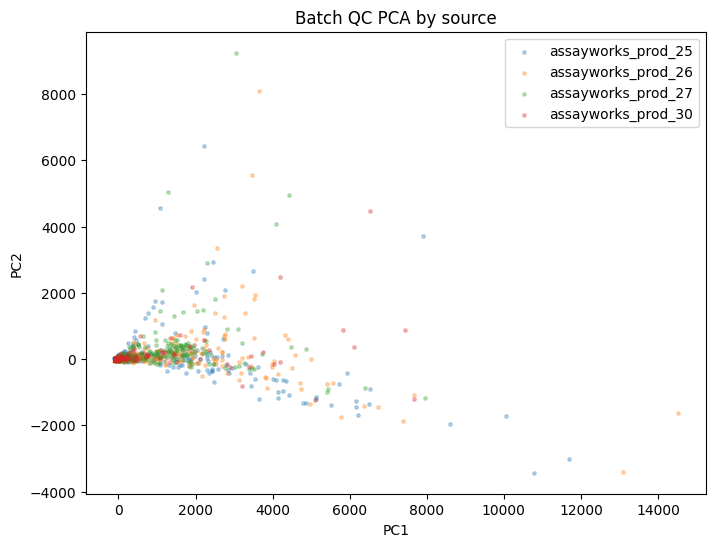

In [ ]:
# Metadata_source
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for source, g in df_batch_pca.groupby("Metadata_source"):
    plt.scatter(
        g["PC1"],
        g["PC2"],
        s=6,
        alpha=0.3,
        label=source
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Batch QC PCA by source")
plt.legend()
plt.show()

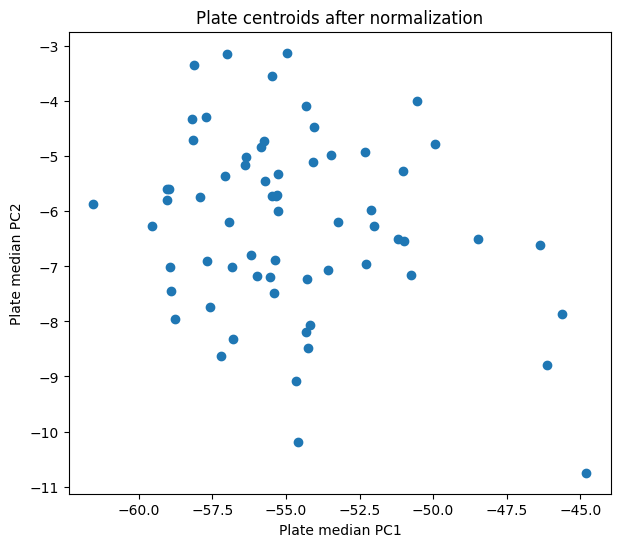

In [ ]:
# Metadata_plate (too many -> centroid)
plate_centroids = (
    df_batch_pca
    .groupby("Metadata_Plate")[["PC1", "PC2"]]
    .median()
)

plt.figure(figsize=(7, 6))
plt.scatter(
    plate_centroids["PC1"],
    plate_centroids["PC2"]
)

plt.xlabel("Plate median PC1")
plt.ylabel("Plate median PC2")
plt.title("Plate centroids after normalization")
plt.show()

In [ ]:
# DMSO only PCA
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

dmso_qc = df_norm[
    df_norm["Metadata_Compound"] == "DMSO"
].copy()

X_dmso = dmso_qc[batch_qc_features].astype(float)

pca_dmso = PCA(n_components=5)
Z_dmso = pca_dmso.fit_transform(X_dmso)

dmso_qc["PC1"] = Z_dmso[:, 0]
dmso_qc["PC2"] = Z_dmso[:, 1]

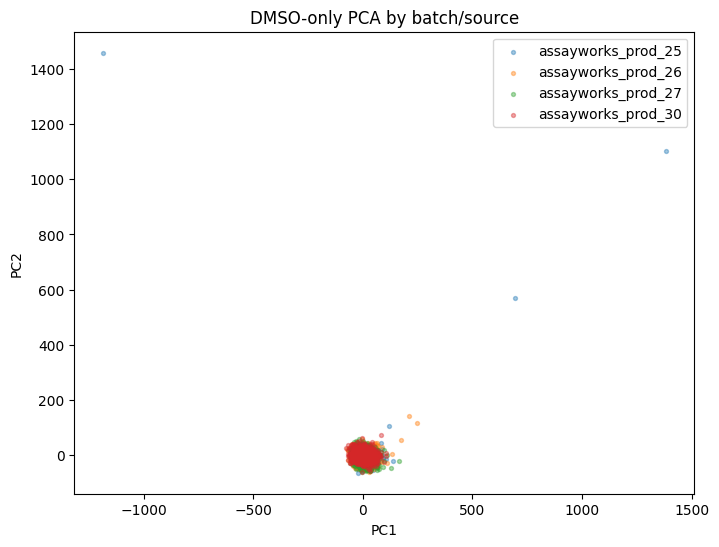

In [ ]:
# by batch/source
plt.figure(figsize=(8, 6))

for source, g in dmso_qc.groupby("Metadata_source"):
    plt.scatter(
        g["PC1"],
        g["PC2"],
        s=8,
        alpha=0.4,
        label=source
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DMSO-only PCA by batch/source")
plt.legend()
plt.show()

In [ ]:
# Check outliers
dmso_qc["pca_distance"] = np.sqrt(
    dmso_qc["PC1"]**2 +
    dmso_qc["PC2"]**2
)

dmso_qc[
    [
        "Metadata_Plate",
        "Metadata_Well",
        "Metadata_source",
        "PC1",
        "PC2",
        "pca_distance",
    ]
].sort_values(
    "pca_distance",
    ascending=False
).head(20)

,Metadata_Plate,Metadata_Well,Metadata_source,PC1,PC2,pca_distance
4898,plate_41002700,B04,assayworks_prod_25,-1187.361340,1459.840700,1881.744356
1596,plate_41002692,H13,assayworks_prod_25,1383.791843,1102.525140,1769.305386
1585,plate_41002692,H02,assayworks_prod_25,695.370311,569.232894,898.646736
13107,plate_41002875,O04,assayworks_prod_26,247.530180,113.929736,272.490688
12779,plate_41002875,A12,assayworks_prod_26,210.440357,140.042207,252.778487
9369,plate_41002891,P10,assayworks_prod_26,173.402560,52.128312,181.068520
2741,plate_41002895,H06,assayworks_prod_27,166.666035,-23.492416,168.313579
18296,plate_41002687,E14,assayworks_prod_25,120.326030,103.084293,158.444706
12608,plate_41002908,A01,assayworks_prod_27,130.552902,-49.217794,139.522226
19803,plate_41002697,K04,assayworks_prod_25,135.468342,-21.278549,137.129313


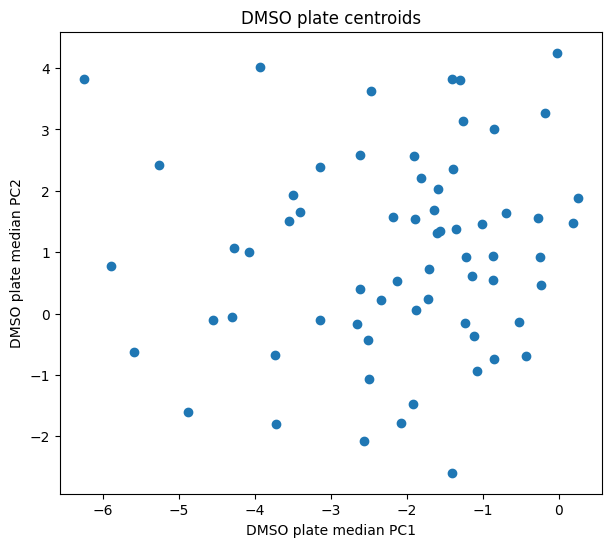

In [ ]:
# by plate
dmso_plate_centroids = (
    dmso_qc
    .groupby("Metadata_Plate")[["PC1", "PC2"]]
    .median()
)

plt.figure(figsize=(7, 6))

plt.scatter(
    dmso_plate_centroids["PC1"],
    dmso_plate_centroids["PC2"]
)

plt.xlabel("DMSO plate median PC1")
plt.ylabel("DMSO plate median PC2")
plt.title("DMSO plate centroids")

plt.show()

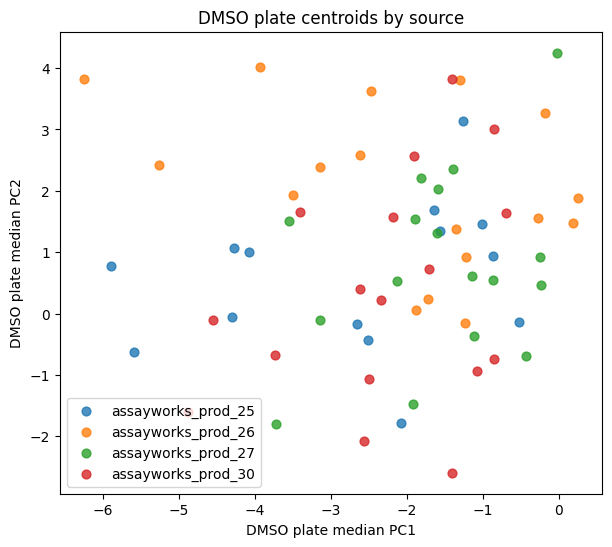

In [ ]:
plate_info = (
    dmso_qc
    .groupby("Metadata_Plate")["Metadata_source"]
    .first()
)

dmso_plate_centroids_plot = (
    dmso_plate_centroids
    .join(plate_info)
)

plt.figure(figsize=(7, 6))

for source, g in dmso_plate_centroids_plot.groupby("Metadata_source"):
    plt.scatter(
        g["PC1"],
        g["PC2"],
        label=source,
        s=40,
        alpha=0.8
    )

plt.xlabel("DMSO plate median PC1")
plt.ylabel("DMSO plate median PC2")
plt.title("DMSO plate centroids by source")
plt.legend()
plt.show()

In [ ]:
# Batch/plate QC
# - Plate-wise DMSO normalization performed.
# - DMSO profiles showed no clear source-specific separation.
# - DMSO plate centroids showed limited residual plate variation.
# - A small number of extreme DMSO wells were observed and inspected separately.

# Feature selection

In [ ]:
from pycytominer import feature_select

df_selected = feature_select(
    profiles=df_norm,
    features=feature_cols_cv,
    operation=[
        "variance_threshold",
        "correlation_threshold",
    ],
)

In [ ]:
selected_feature_cols = [
    f for f in feature_cols_cv
    if f in df_selected.columns
]

print("Before feature selection:", len(feature_cols_cv))
print("After feature selection :", len(selected_feature_cols))
print(
    "Removed:",
    len(feature_cols_cv)
    - len(selected_feature_cols)
)

Before feature selection: 3142
After feature selection : 426
Removed: 2716


In [ ]:
feature_groups_selected = {
    group: [
        f for f in feats
        if f in selected_feature_cols
    ]
    for group, feats in feature_groups.items()
}

In [ ]:
# check selected features per feature group
for group in sorted(feature_groups_selected):
    print(
        group,
        len(feature_groups_selected[group])
    )

Cells_AGP 20
Cells_AreaShape 28
Cells_DNA 24
Cells_ER 18
Cells_Mito 24
Cells_RNA 15
Cytoplasm_AGP 24
Cytoplasm_AreaShape 29
Cytoplasm_DNA 33
Cytoplasm_ER 27
Cytoplasm_Mito 32
Cytoplasm_RNA 19
Nuclei_AGP 20
Nuclei_AreaShape 36
Nuclei_DNA 29
Nuclei_ER 10
Nuclei_Mito 14
Nuclei_RNA 24


# Q. 디노 할때도 pycytominer로 해서 통일해야? 위의 CV filtering 안햇는데 해야하나?
# 중요: Ewald는 global에서 image feature이나 correlation feature 다 활용했음. 나는 channel별 분석하는거라서 제외하였으므로 다를것임.

# Replicate QC

In [ ]:
rep_counts = (
    df_selected
    .loc[df_selected["Metadata_Compound"] != "DMSO"]
    .groupby("Metadata_Perturbation")
    .size()
)

print(rep_counts.value_counts().sort_index())

1     950
2    7721
8       8
Name: count, dtype: int64


In [ ]:
# Why replicate = 8?
rep_counts = (
    df_selected
    .loc[df_selected["Metadata_Compound"] != "DMSO"]
    .groupby("Metadata_Perturbation")
    .size()
)

rep8 = rep_counts[rep_counts == 8].index

df_selected.loc[
    df_selected["Metadata_Perturbation"].isin(rep8),
    [
        "Metadata_Perturbation",
        "Metadata_Compound",
        "Metadata_Concentration",
        "Metadata_Plate",
        "Metadata_Well",
    ]
].sort_values(
    ["Metadata_Perturbation", "Metadata_Plate"]
)

,Metadata_Perturbation,Metadata_Compound,Metadata_Concentration,Metadata_Plate,Metadata_Well
9602,Compound_04264751_0.0456431545317173,Compound_04264751,0.045643,plate_41002883,J10
9687,Compound_04264751_0.0456431545317173,Compound_04264751,0.045643,plate_41002883,M23
9734,Compound_04264751_0.0456431545317173,Compound_04264751,0.045643,plate_41002883,O22
16057,Compound_04264751_0.0456431545317173,Compound_04264751,0.045643,plate_41002884,P24
16474,Compound_04264751_0.0456431545317173,Compound_04264751,0.045643,plate_41002902,B09
16513,Compound_04264751_0.0456431545317173,Compound_04264751,0.045643,plate_41002902,C24
16695,Compound_04264751_0.0456431545317173,Compound_04264751,0.045643,plate_41002902,K14
16759,Compound_04264751_0.0456431545317173,Compound_04264751,0.045643,plate_41002902,N06
13039,Compound_04264751_0.1369294673204422,Compound_04264751,0.136929,plate_41002875,L08
4544,Compound_04264751_0.1369294673204422,Compound_04264751,0.136929,plate_41002876,C10


In [ ]:
# Remove Compound_04264751 from analysis for simplified calculation for replicates
df_analysis = df_selected.loc[
    df_selected["Metadata_Compound"] != "Compound_04264751"
].copy()

rep_counts = (
    df_analysis
    .loc[df_analysis["Metadata_Compound"] != "DMSO"]
    .groupby("Metadata_Perturbation")
    .size()
)

print(rep_counts.value_counts().sort_index())

1     950
2    7721
Name: count, dtype: int64


In [ ]:
# How similar between perturbations? - Pearson correlation
from scipy.stats import pearsonr
import pandas as pd

pair_ids = rep_counts[rep_counts == 2].index

replicate_corrs = []

for perturbation in pair_ids:

    g = df_analysis[
        df_analysis["Metadata_Perturbation"] == perturbation
    ]

    x = g.iloc[0][selected_feature_cols].astype(float)
    y = g.iloc[1][selected_feature_cols].astype(float)

    r, _ = pearsonr(x, y)

    replicate_corrs.append({
        "Metadata_Perturbation": perturbation,
        "replicate_correlation": r
    })

replicate_corr_df = pd.DataFrame(replicate_corrs)

In [ ]:
replicate_corr_df["replicate_correlation"].describe()

,replicate_correlation
count,7721.000000
mean,0.146428
std,0.322565
min,-0.696301
25%,-0.082433
50%,0.121902
75%,0.348013
max,0.979937


In [ ]:
# Same perturbation replicate correlations vs random perturbation correlations
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

rng = np.random.default_rng(42)

# replicate = 2인 perturbation만
pair_ids = rep_counts[rep_counts == 2].index

rep_df = df_analysis[
    df_analysis["Metadata_Perturbation"].isin(pair_ids)
].copy()

# random non-replicate pairs
n_random = len(pair_ids)

random_corrs = []

indices = rep_df.index.to_numpy()

while len(random_corrs) < n_random:

    i, j = rng.choice(indices, size=2, replace=False)

    # 같은 perturbation이면 제외
    if (
        rep_df.loc[i, "Metadata_Perturbation"]
        == rep_df.loc[j, "Metadata_Perturbation"]
    ):
        continue

    x = rep_df.loc[i, selected_feature_cols].astype(float)
    y = rep_df.loc[j, selected_feature_cols].astype(float)

    r, _ = pearsonr(x, y)
    random_corrs.append(r)

random_corrs = np.array(random_corrs)

In [ ]:
null_threshold = np.percentile(random_corrs, 95)

print("Random median:", np.median(random_corrs))
print("Random 95th percentile:", null_threshold)

Random median: 0.026508089639843604
Random 95th percentile: 0.44010453241275765


In [ ]:
replicate_corr_df["reproducible"] = (
    replicate_corr_df["replicate_correlation"]
    > null_threshold
)

percent_replicating = (
    replicate_corr_df["reproducible"].mean() * 100
)

print("Percent replicating:", percent_replicating)

Percent replicating: 17.653153736562622


In [ ]:
# By concentration
replicate_corr_df = replicate_corr_df.merge(
    df_analysis[
        [
            "Metadata_Perturbation",
            "Metadata_Compound",
            "Metadata_Concentration",
        ]
    ].drop_duplicates(),
    on="Metadata_Perturbation",
    how="left",
)

replicate_corr_df.groupby(
    "Metadata_Concentration"
)["replicate_correlation"].describe()

,count,mean,std,min,25%,50%,75%,max
Metadata_Concentration,,,,,,,,
0.009129,15.0,0.077148,0.231009,-0.317326,-0.081478,0.049107,0.281451,0.392803
0.027386,15.0,0.099632,0.154157,-0.140519,0.006916,0.083406,0.170134,0.519158
0.045643,1069.0,0.019130,0.245261,-0.690889,-0.155763,0.009052,0.190141,0.941737
0.082158,15.0,0.065457,0.243669,-0.297753,-0.167113,0.114635,0.275769,0.425460
0.136929,754.0,0.079042,0.270665,-0.696301,-0.089296,0.078776,0.260173,0.929100
0.200000,15.0,0.400973,0.078441,0.272202,0.343584,0.398161,0.463113,0.538383
0.410788,1069.0,0.053488,0.268764,-0.628771,-0.126788,0.040132,0.230147,0.901758
0.700000,15.0,-0.012927,0.321638,-0.444724,-0.233940,-0.073319,0.141353,0.804007
1.000000,1069.0,0.121445,0.287691,-0.657551,-0.073942,0.116285,0.323864,0.952470


In [ ]:
# Random pair from the same concentration level
rng = np.random.default_rng(42)

random_corrs = []

# replicate=2인 perturbation들만 사용
rep_df = df_analysis[
    df_analysis["Metadata_Perturbation"].isin(pair_ids)
].copy()

# 실제 replicate pair 개수만큼 null 생성
for perturbation in pair_ids:

    g = rep_df[
        rep_df["Metadata_Perturbation"] == perturbation
    ]

    concentration = g["Metadata_Concentration"].iloc[0]

    # 같은 농도지만 다른 perturbation들
    candidates = rep_df[
        (rep_df["Metadata_Concentration"] == concentration)
        & (rep_df["Metadata_Perturbation"] != perturbation)
    ]

    if len(candidates) < 2:
        continue

    sampled = candidates.sample(
        n=2,
        replace=False,
        random_state=rng.integers(0, 1_000_000)
    )

    x = sampled.iloc[0][selected_feature_cols].astype(float)
    y = sampled.iloc[1][selected_feature_cols].astype(float)

    r, _ = pearsonr(x, y)

    random_corrs.append(r)

random_corrs = np.array(random_corrs)

null_threshold = np.percentile(random_corrs, 95)

print("Dose-matched random median:",
      np.median(random_corrs))

print("Dose-matched random 95th percentile:",
      null_threshold)

Dose-matched random median: 0.04918431887271465
Dose-matched random 95th percentile: 0.4895269774577919


In [ ]:
replicate_corr_df["reproducible"] = (
    replicate_corr_df["replicate_correlation"]
    > null_threshold
)

percent_replicating = (
    replicate_corr_df["reproducible"].mean() * 100
)

print("Percent replicating:", percent_replicating)

Percent replicating: 14.531796399430124


In [ ]:
# large number of low effect from treatments (low-dose/no-phenotype) might result in low replicating percent

# Replicate aggregation

In [ ]:
treat_df = df_analysis.loc[
    df_analysis["Metadata_Compound"] != "DMSO"
].copy()

In [ ]:
replicate_n = (
    treat_df
    .groupby("Metadata_Perturbation")
    .size()
    .rename("Metadata_Replicate_Count")
)

In [ ]:
consensus_features = (
    treat_df
    .groupby("Metadata_Perturbation")[selected_feature_cols]
    .median()
    .reset_index()
)

In [ ]:
metadata_keep = [
    "Metadata_Compound",
    "Metadata_Concentration",
    "Metadata_compound_target",
    "Metadata_compound_pathway",
    "Metadata_compound_research_area",
    "Metadata_compound_clinical_information",
    "Metadata_OASIS_ID",
]

consensus_meta = (
    treat_df
    .groupby("Metadata_Perturbation")[metadata_keep]
    .first()
    .reset_index()
)

In [ ]:
df_consensus = (
    consensus_meta
    .merge(
        consensus_features,
        on="Metadata_Perturbation",
        how="inner"
    )
    .merge(
        replicate_n.reset_index(),
        on="Metadata_Perturbation",
        how="left"
    )
)

In [ ]:
print(df_consensus.shape)

print(
    df_consensus["Metadata_Replicate_Count"]
    .value_counts()
    .sort_index()
)

(8671, 435)
Metadata_Replicate_Count
1     950
2    7721
Name: count, dtype: int64


In [ ]:
len(df_consensus)

8671

In [ ]:
import gc

# 1. Jupyter output history 비우기
%reset -f out

# 2. df_cellprofiler를 IPython 참조까지 포함해서 삭제
%xdel df_cellprofiler

# 3. 혹시 남은 자동 출력 변수 삭제
globals().pop("_79", None)


vars_to_delete = [
    "df_cellprofiler"
    "df_norm",
    "df_selected",
    "df_var",
    "df_corr",
    "rep_df",
    "replicate_corr_df",
    "random_corrs",
    "plate_df",
    "cv_qc",
    "dmso_norm",
    "candidates",
    "treat_df",
    "consensus_features",
]

for var in vars_to_delete:
    if var in globals():
        del globals()[var]

gc.collect()

Flushing output cache (20 entries)


0

In [ ]:
import sys

for name, obj in list(globals().items()):
    if hasattr(obj, "memory_usage"):
        try:
            size_mb = obj.memory_usage(deep=True).sum() / 1024**2
            if size_mb > 10:
                print(f"{name}: {size_mb:.1f} MB")
        except:
            pass

X: 512.0 MB
df_norm: 717.5 MB
X_batch: 510.7 MB
dmso_qc: 162.7 MB
X_dmso: 116.3 MB
df_analysis: 275.4 MB
df_consensus: 32.1 MB


# PCA

In [ ]:
# Create PCA input matrix
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd

X = df_consensus[selected_feature_cols].astype(float)

print(X.shape)
print("NaN:", X.isna().sum().sum())
print("Inf:", np.isinf(X).sum().sum())

(8671, 426)
NaN: 0
Inf: 0


In [ ]:
# 50 PCs
n_pcs = 50

pca = PCA(n_components=n_pcs)

X_pca = pca.fit_transform(X)

In [ ]:
# Combine PCA results with metadata
pc_cols = [f"PC{i+1}" for i in range(n_pcs)]

df_pca_scores = pd.DataFrame(
    X_pca,
    columns=pc_cols,
    index=df_consensus.index
)

metadata_cols = [
    c for c in df_consensus.columns
    if c not in selected_feature_cols
]

df_pca = pd.concat(
    [
        df_consensus[metadata_cols].reset_index(drop=True),
        df_pca_scores.reset_index(drop=True)
    ],
    axis=1
)

In [ ]:
# Check explained variance
explained = pca.explained_variance_ratio_

for i in range(10):
    print(
        f"PC{i+1}: "
        f"{explained[i]*100:.2f}%"
    )

PC1: 52.85%
PC2: 11.73%
PC3: 6.45%
PC4: 4.46%
PC5: 4.17%
PC6: 3.48%
PC7: 2.25%
PC8: 1.51%
PC9: 1.29%
PC10: 1.06%


In [ ]:
cumvar = np.cumsum(explained)

for n in [2, 5, 10, 20, 30, 50]:
    print(
        f"{n} PCs: "
        f"{cumvar[n-1]*100:.2f}%"
    )

2 PCs: 64.59%
5 PCs: 79.66%
10 PCs: 89.25%
20 PCs: 95.05%
30 PCs: 96.88%
50 PCs: 98.24%


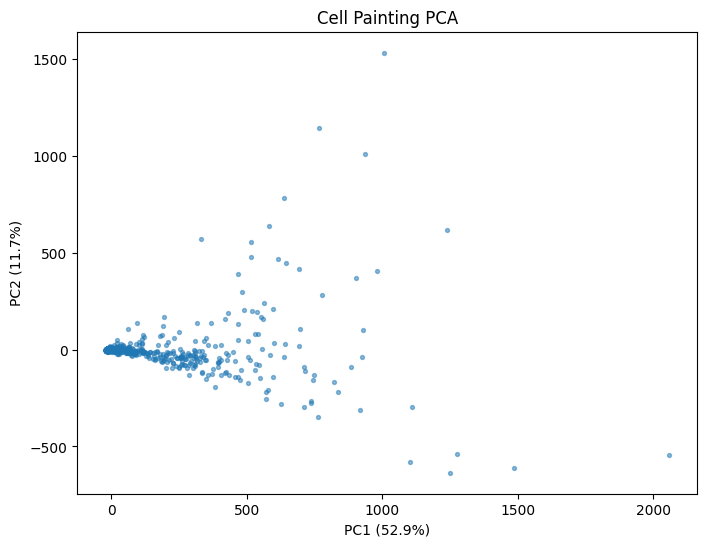

In [ ]:
# PC1-PC2
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    df_pca["PC1"],
    df_pca["PC2"],
    s=8,
    alpha=0.5
)

plt.xlabel(
    f"PC1 ({explained[0]*100:.1f}%)"
)
plt.ylabel(
    f"PC2 ({explained[1]*100:.1f}%)"
)

plt.title("Cell Painting PCA")
plt.show()

In [ ]:
# Check PC1/PC2 extreme profile
df_pca[
    [
        "Metadata_Compound",
        "Metadata_Concentration",
        "Metadata_Perturbation",
        "PC1",
        "PC2",
    ]
].sort_values("PC1", ascending=False).head(20)

,Metadata_Compound,Metadata_Concentration,Metadata_Perturbation,PC1,PC2
2228,Compound_26e57091,100.0,Compound_26e57091_100.0,2058.141031,-544.505515
7243,SSR240612,100.0,SSR240612_100.0,1487.061298,-613.610993
3772,Erdafitinib,100.0,Erdafitinib_100.0,1276.298618,-540.555240
7635,Sunitinib,100.0,Sunitinib_100.0,1249.151120,-635.743339
2628,Compound_a8277eea,100.0,Compound_a8277eea_100.0,1238.657297,619.164535
6763,Proguanil,100.0,Proguanil_100.0,1109.593703,-294.368229
6507,Piperacetazine,100.0,Piperacetazine_100.0,1103.382978,-581.893847
2999,Crizotinib,33.5,Crizotinib_33.5,1006.642490,1533.054584
1293,Bortezomib,11.0,Bortezomib_11.0,981.180390,408.321528
4204,Fluazinam,100.0,Fluazinam_100.0,937.311584,1008.809609


In [ ]:
df_pca.loc[
    df_pca["PC2"].abs().sort_values(ascending=False).index,
    [
        "Metadata_Compound",
        "Metadata_Concentration",
        "Metadata_Perturbation",
        "PC1",
        "PC2",
    ]
].head(20)

,Metadata_Compound,Metadata_Concentration,Metadata_Perturbation,PC1,PC2
2999,Crizotinib,33.5,Crizotinib_33.5,1006.642490,1533.054584
2375,Compound_516bb906,33.5,Compound_516bb906_33.5,767.648161,1142.279533
4204,Fluazinam,100.0,Fluazinam_100.0,937.311584,1008.809609
1556,Carfilzomib,100.0,Carfilzomib_100.0,639.386267,782.702290
2373,Compound_516bb906,11.0,Compound_516bb906_11.0,583.923982,638.227498
7635,Sunitinib,100.0,Sunitinib_100.0,1249.151120,-635.743339
2628,Compound_a8277eea,100.0,Compound_a8277eea_100.0,1238.657297,619.164535
7243,SSR240612,100.0,SSR240612_100.0,1487.061298,-613.610993
6507,Piperacetazine,100.0,Piperacetazine_100.0,1103.382978,-581.893847
7819,Tenapanor (hydrochloride),100.0,Tenapanor (hydrochloride)_100.0,330.525335,569.393216


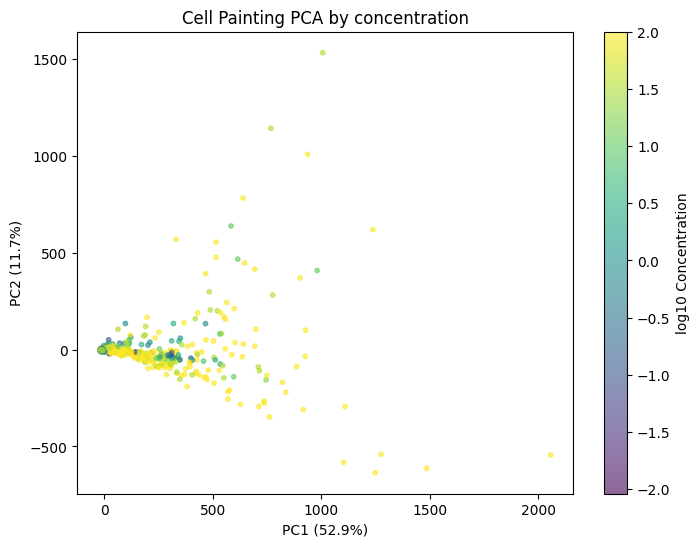

In [ ]:
# PCA by concentration
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))

sc = plt.scatter(
    df_pca["PC1"],
    df_pca["PC2"],
    c=np.log10(df_pca["Metadata_Concentration"]),
    s=10,
    alpha=0.6
)

plt.colorbar(sc, label="log10 Concentration")

plt.xlabel(f"PC1 ({explained[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({explained[1]*100:.1f}%)")
plt.title("Cell Painting PCA by concentration")

plt.show()

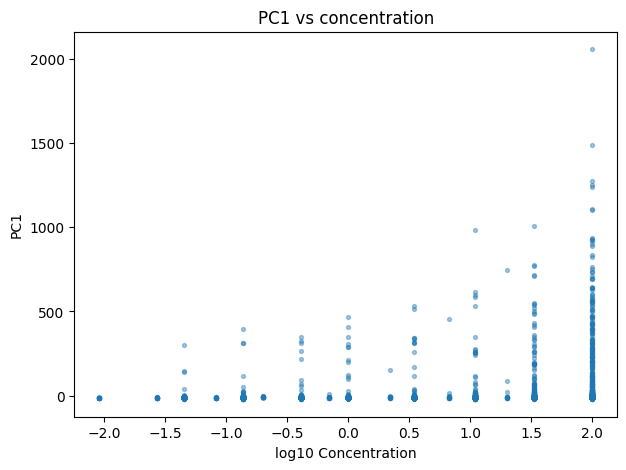

In [ ]:
# PC1 ~ concentration
plt.figure(figsize=(7, 5))

plt.scatter(
    np.log10(df_pca["Metadata_Concentration"]),
    df_pca["PC1"],
    s=8,
    alpha=0.4
)

plt.xlabel("log10 Concentration")
plt.ylabel("PC1")
plt.title("PC1 vs concentration")

plt.show()

In [ ]:
profile_max_abs = (
    df_consensus[selected_feature_cols]
    .abs()
    .max(axis=1)
)

profile_max_abs.describe(
    percentiles=[0.9, 0.95, 0.99, 0.995, 0.999]
)

,0
count,8671.000000
mean,11.577709
std,65.181990
min,1.429007
50%,2.751494
90%,6.079338
95%,17.398946
99%,251.187548
99.5%,428.842914
99.9%,941.774680


In [ ]:
extreme_idx = profile_max_abs.nlargest(20).index

df_consensus.loc[
    extreme_idx,
    [
        "Metadata_Compound",
        "Metadata_Concentration",
        "Metadata_Perturbation",
    ]
].assign(
    max_abs_feature=profile_max_abs.loc[extreme_idx]
)

,Metadata_Compound,Metadata_Concentration,Metadata_Perturbation,max_abs_feature
2999,Crizotinib,33.5,Crizotinib_33.5,1942.679752
2228,Compound_26e57091,100.0,Compound_26e57091_100.0,1479.236770
2375,Compound_516bb906,33.5,Compound_516bb906_33.5,1381.500633
7635,Sunitinib,100.0,Sunitinib_100.0,1349.542165
4204,Fluazinam,100.0,Fluazinam_100.0,1258.394381
7243,SSR240612,100.0,SSR240612_100.0,1154.244888
3772,Erdafitinib,100.0,Erdafitinib_100.0,1010.789472
5227,Lurbinectedin,100.0,Lurbinectedin_100.0,975.584189
6763,Proguanil,100.0,Proguanil_100.0,951.352413
6507,Piperacetazine,100.0,Piperacetazine_100.0,937.057290


In [ ]:
# Check if PC1 is cytotoxic effects

In [ ]:
tox_cols = [
    "Metadata_mtt_normalized",
    "Metadata_ldh_normalized",
    "Metadata_Count_Cells",
]

toxicity_consensus = (
    df_analysis
    .groupby("Metadata_Perturbation", as_index=False)[tox_cols]
    .median()
)

In [ ]:
df_consensus = df_consensus.merge(
    toxicity_consensus,
    on="Metadata_Perturbation",
    how="left",
    validate="one_to_one"
)

In [ ]:
df_consensus[tox_cols].head()

,Metadata_mtt_normalized,Metadata_ldh_normalized,Metadata_Count_Cells
0,1.029124,-0.037942,799.0
1,1.054532,0.072874,787.5
2,0.992486,-0.047541,830.0
3,1.065095,0.008763,849.0
4,1.024861,-0.017193,847.5


In [ ]:
df_pca = df_pca.merge(
    toxicity_consensus,
    on="Metadata_Perturbation",
    how="left",
    validate="one_to_one"
)

In [ ]:
df_pca[
    [
        "PC1",
        "Metadata_mtt_normalized",
        "Metadata_ldh_normalized",
        "Metadata_Count_Cells",
    ]
].corr(method="spearman")["PC1"]

,PC1
PC1,1.000000
Metadata_mtt_normalized,-0.195485
Metadata_ldh_normalized,0.227822
Metadata_Count_Cells,-0.595673


In [ ]:
# PC1 ↑
# ↓
# Cell count ↓
# LDH ↑
# MTT/viability ↓
# -> PC1 contains a strong cell-loss / high-dose stress component

# Save files

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from pathlib import Path

PROJECT = Path("/content/drive/MyDrive/2026_project_cell_painting/CellProfiler")
PROCESSED = PROJECT / "processed"

PROCESSED.mkdir(parents=True, exist_ok=True)

In [ ]:
df_consensus.to_parquet(
    PROCESSED / "df_consensus.parquet",
    index=False
)

In [ ]:
import json

feature_info = {
    "selected_feature_cols": selected_feature_cols,
    "feature_groups_selected": feature_groups_selected,
}

with open(PROCESSED / "feature_info.json", "w") as f:
    json.dump(feature_info, f, indent=2)